# 1、TextSplitter的使用

1、使用细节

①TextSplitter作为各种具体的文档拆分器的父类

②内部定义了一些常用的属性

chunk_size: 返回块的最大尺寸，单位是字符数。默认值为4000（由长度函数测量）

chunk_overlap: 相邻两个块之间的字符重叠数,避免信息在边界处被切断而丢失。默认值为200,通常会设置为chunk_size的10% - 20%。

length_function: 用于测量给定块字符数的函数。默认赋值为len函数。len函数在Python中按Unicode字符计数，所以一个汉字、一个英文字母、一个符号都算一个字符。

keep_separator: 是否在块中保留分隔符，默认值为False

add_start_index: 如果为 `True`，则在元数据中包含块的起始索引。默认值为False

strip_whitespace: 如果为 `True`，则从每个文档的开始和结束处去除空白字符。默认值为True

③内部定义的一些常用方法

情况1：按照字符串进行拆分；

split_text(xx):传入的参数是字符串类型，返回值的类型是List[str]

create_documents(xx):传入参数类型是List[str],返回值类型是List[Documennt];底层调用了split_text()

情况2：按照Document对象进行拆分。

split_documents(xx):传入参数类型是List[Document]，返回值类型是List[Document];底层调用了create_document(xx)
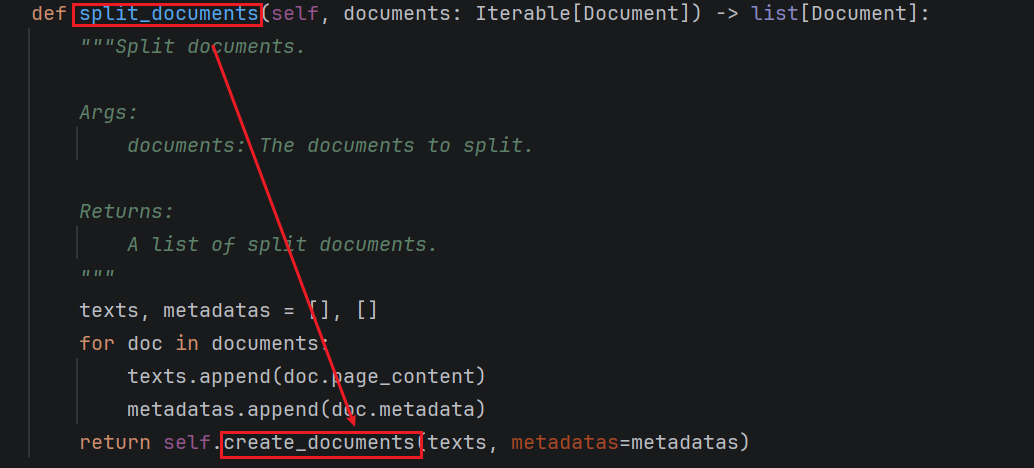

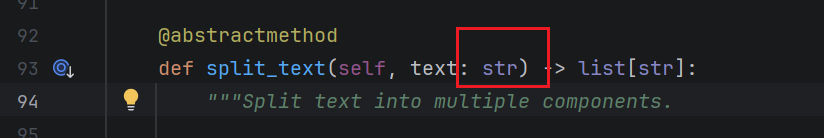
2、Document对象与 Str是什么关系？

文档切分器可以按照字符进行切分，也可以按照Document进行切分。Str可以理解为Document对象的page_content属性

# 2、具体的拆分器之 CharacterTextSplitter：Split by character

示例1：体会chunk_size chunk_overlap

In [4]:
# 1.导入相关依赖
from langchain_text_splitters import CharacterTextSplitter
# 2.示例文本
text = """
LangChain 是一个用于开发由语言模型驱动的应用程序的框架的。它提供了一套工具和抽象，使开发者能够更容易地构建复杂的应用程序。
"""
# 3.定义字符分割器
splitter = CharacterTextSplitter(
    chunk_size=50, # 每块大小
    chunk_overlap=5,# 块与块之间的重复字符数
    #length_function=len,
    separator="" # 设置为空字符串时，表示禁用分隔符优先
)
# 4.分割文本
texts = splitter.split_text(text)
# 5.打印结果
for i, chunk in enumerate(texts):
    print(f"块 {i+1}:长度：{len(chunk)}")
    print(chunk)
    print("-"* 50)

块 1:长度：49
LangChain 是一个用于开发由语言模型驱动的应用程序的框架的。它提供了一套工具和抽象，使开发
--------------------------------------------------
块 2:长度：22
象，使开发者能够更容易地构建复杂的应用程序。
--------------------------------------------------


示例2：体会separator

In [5]:
# 1.导入相关依赖
from langchain_text_splitters import CharacterTextSplitter
# 2.定义要分割的文本
text = "这是一个示例文本啊。我们将使用CharacterTextSplitter将其分割成小块。分割基于字符数。"
# text = """
# LangChain 是一个用于开发由语言模型。驱动的应用程序的框架的。它提供了一套工具和抽象。使开发者能够更容易地构建复杂的应用程序。
# """
# 3.定义分割器实例
text_splitter = CharacterTextSplitter(
    chunk_size=30,   # 每个块的最大字符数
    chunk_overlap=5, # 块之间的重叠字符数
    separator="。",  # 按句号分割 分隔符优先
)
# 4.开始分割
chunks = text_splitter.split_text(text)
# 5.打印效果
for  i,chunk in enumerate(chunks):
    print(f"块 {i + 1}:长度：{len(chunk)}")
    print(chunk)
    print("-"*50)

Created a chunk of size 33, which is longer than the specified 30


块 1:长度：9
这是一个示例文本啊
--------------------------------------------------
块 2:长度：33
我们将使用CharacterTextSplitter将其分割成小块
--------------------------------------------------
块 3:长度：7
分割基于字符数
--------------------------------------------------


In [6]:
# 1.导入相关依赖

# 2.定义要分割的文本
text = "这是第一段文本。这是第二段内容。最后一段结束。"
# 3.定义字符分割器
text_splitter = CharacterTextSplitter(
    separator="。",
    chunk_size=20,
    chunk_overlap=8,# 可以生效
    keep_separator=True #chunk中是否保留切割符
)
# 4.分割文本
chunks = text_splitter.split_text(text)
# 5.打印结果
for  i,chunk in enumerate(chunks):
    print(f"块 {i + 1}:长度：{len(chunk)}")
    print(chunk)
    print("-"*50)

块 1:长度：15
这是第一段文本。这是第二段内容
--------------------------------------------------
块 2:长度：16
。这是第二段内容。最后一段结束。
--------------------------------------------------


# 3、具体的拆分器之RecursiveCharacterTextSplitter:最常用

举例1：使用split_text()方法演示

In [7]:
# 1.导入相关依赖
from langchain_text_splitters import RecursiveCharacterTextSplitter
# 2.定义RecursiveCharacterTextSplitter分割器对象
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=10,
    chunk_overlap=0,
    add_start_index=True,
)
# 3.定义拆分的内容
text="LangChain框架特性\n\n多模型集成(GPT/Claude)\n记忆管理功能\n链式调用设计。文档分析场景示例：需要处理PDF/Word等格式。"
# 4.拆分器分割
paragraphs = text_splitter.split_text(text)
for para in paragraphs:
    print(para)
    print('-------')

LangChain框
-------
架特性
-------
多模型集成(GPT
-------
/Claude)
-------
记忆管理功能
-------
链式调用设计。文档
-------
分析场景示例：需要处
-------
理PDF/Word等
-------
格式。
-------


举例2：使用create_documents()方法演示，传入字符串列表，返回Document对象列表

In [8]:
# 1.导入相关依赖

# 2.定义RecursiveCharacterTextSplitter分割器对象
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=10,
    chunk_overlap=0,
    add_start_index=True,
)
# 3.定义分割的内容
# text="LangChain框架特性\n\n多模型集成(GPT/Claude)\n记忆管理功能\n链式调用设计。文档分析场景示例：需要处理PDF/Word等格式。"
list=["LangChain框架特性\n\n多模型集成(GPT/Claude)\n记忆管理功能\n链式调用设计。文档分析场景示例：需要处理PDF/Word等格式。"]
# 4.分割器分割
# create_documents()：形参是字符串列表，返回值是Document的列表
paragraphs = text_splitter.create_documents(list)
for para in paragraphs:
    print(para)
    print('-------')

page_content='LangChain框' metadata={'start_index': 0}
-------
page_content='架特性' metadata={'start_index': 10}
-------
page_content='多模型集成(GPT' metadata={'start_index': 15}
-------
page_content='/Claude)' metadata={'start_index': 24}
-------
page_content='记忆管理功能' metadata={'start_index': 33}
-------
page_content='链式调用设计。文档' metadata={'start_index': 40}
-------
page_content='分析场景示例：需要处' metadata={'start_index': 49}
-------
page_content='理PDF/Word等' metadata={'start_index': 59}
-------
page_content='格式。' metadata={'start_index': 69}
-------


举例3：使用create_documents()方法演示，将本地文件内容加载成字符串，进行拆分

In [9]:
# 1.导入相关依赖
from langchain_text_splitters import RecursiveCharacterTextSplitter
# 2.打开.txt文件
with open(
        "asset/load/08-ai.txt",
        encoding="utf-8"
) as f:state_of_the_union = f.read()  #返回的是字符串
# 3.定义RecursiveCharacterTextSplitter（递归字符分割器）
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=20,#chunk_overlap=0,
    length_function=len
)
# 4.分割文本
texts = text_splitter.create_documents([state_of_the_union])
# 5.打印分割文本
for text in texts:
    print(f"🔥{text.page_content}")

🔥人工智能（AI）是什么？
🔥人工智能（Artificial
🔥Intelligence，简称AI）是指由计算机系统模拟人类智能的技术，使其能够执行通常需要人类认知能力的任务，如学习、推理、决策和语言理解。AI的核心目标是让机器具备感知环境、处理信息并自主行动的
🔥让机器具备感知环境、处理信息并自主行动的能力。
🔥1. AI的技术基础
AI依赖多种关键技术：

机器学习（ML）：通过算法让计算机从数据中学习规律，无需显式编程。例如，推荐系统通过用户历史行为预测偏好。
🔥深度学习：基于神经网络的机器学习分支，擅长处理图像、语音等复杂数据。AlphaGo击败围棋冠军便是典型案例。

自然语言处理（NLP）：使计算机理解、生成人类语言，如ChatGPT的对话能力。
🔥2. AI的应用场景
AI已渗透到日常生活和各行各业：

医疗：辅助诊断（如AI分析医学影像）、药物研发加速。

交通：自动驾驶汽车通过传感器和AI算法实现安全导航。
🔥金融：欺诈检测、智能投顾（如风险评估模型）。

教育：个性化学习平台根据学生表现调整教学内容。

3. AI的挑战与未来
尽管前景广阔，AI仍面临问题：
🔥伦理争议：数据隐私、算法偏见（如招聘AI歧视特定群体）。

就业影响：自动化可能取代部分人工岗位，但也会创造新职业。

技术瓶颈：通用人工智能（AGI）尚未实现，当前AI仅擅长特定任务。
🔥未来，AI将与人类协作而非替代：医生借助AI提高诊断效率，教师利用AI定制课程。其发展需平衡技术创新与社会责任，确保技术造福全人类。


举例4：使用split_documents()方法演示，利用PDFLoader加载文档，对文档的内容用递归切割器切割

In [10]:
# 1.导入相关依赖
from langchain_community.document_loaders import PyPDFLoader
# 2.定义PyPDFLoader加载器
loader = PyPDFLoader("./asset/load/02-load.pdf")
# 3.加载和切割文档对象
docs = loader.load()
# 返回Document对象构成的list
# print(f"第0页：\n{docs[0]}")
# 4.定义切割器
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=200,#chunk_size=120,
    chunk_overlap=0,# chunk_overlap=100,
    length_function=len,
    add_start_index=True,
)
# 5.对pdf内容进行切割得到文档对象
paragraphs = text_splitter.split_documents(docs)
#paragraphs = text_splitter.create_documents([text])
for para in paragraphs:
    print(para.page_content)
    print('-------')

"他的车，他的命！ 他忽然想起来，一年，二年，至少有三四年；一滴汗，两滴汗，不
知道多少万滴汗，才挣出那辆车。从风里雨里的咬牙，从饭里茶里的自苦，才赚出那辆车。
那辆车是他的一切挣扎与困苦的总结果与报酬，像身经百战的武士的一颗徽章。……他老想
着远远的一辆车，可以使他自由，独立，像自己的手脚的那么一辆车。" 
 
"他吃，他喝，他嫖，他赌，他懒，他狡猾， 因为他没了心，他的心被人家摘了去。他
-------
只剩下那个高大的肉架子，等着溃烂，预备着到乱死岗子去。……体面的、要强的、好梦想
的、利己的、个人的、健壮的、伟大的祥子，不知陪着人家送了多少回殡；不知道何时何地
会埋起他自己来， 埋起这堕落的、 自私的、 不幸的、 社会病胎里的产儿， 个人主义的末路鬼！
"
-------


# 4、具体的拆分器之 TokenTextSplitter/CharacterTextSplitter：Split by tokens

举例1：使用TokenTextSplitter

In [13]:
# 1.导入相关依赖
from langchain_text_splitters import TokenTextSplitter
# 2.初始化 TokenTextSplitter
text_splitter = TokenTextSplitter(
    chunk_size=33,#最大 token 数为 32
    chunk_overlap=0,#重叠 token 数为 0
    encoding_name="cl100k_base",# 使用 OpenAI 的编码器,将文本转换为 token 序列
)
# 3.定义文本
text ="人工智能是一个强大的开发框架。它支持多种语言模型和工具链。人工智能是指通过计算机程序模拟人类智能的一门科学。自20世纪50年代诞生以来，人工智能经历了多次起伏。"
# 4.开始切割
texts = text_splitter.split_text(text)

# 打印分割结果
print(f"原始文本被分割成了 {len(texts)} 个块:")
for i, chunk in enumerate(texts):
    print(f"块 {i+1}: 长度：{len(chunk)} 内容：{chunk}")
    print("-" * 50)

原始文本被分割成了 3 个块:
块 1: 长度：29 内容：人工智能是一个强大的开发框架。它支持多种语言模型和工具链。
--------------------------------------------------
块 2: 长度：32 内容：人工智能是指通过计算机程序模拟人类智能的一门科学。自20世纪50
--------------------------------------------------
块 3: 长度：19 内容：年代诞生以来，人工智能经历了多次起伏。
--------------------------------------------------


举例2：使用CharacterTextSplitter

In [14]:
# 1.导入相关依赖
from langchain_text_splitters import CharacterTextSplitter
import tiktoken
# 用于计算Token数量
# 2.定义通过Token切割器
text_splitter = CharacterTextSplitter.from_tiktoken_encoder(
    encoding_name="cl100k_base", # 使用 OpenAI 的编码器
    chunk_size=18,
    chunk_overlap=0,
    separator="。",  # 指定中文句号为分隔符
    keep_separator=False,  # chunk中是否保留分隔符
)
# 3.定义文本
text = "人工智能是一个强大的开发框架。它支持多种语言模型和工具链。今天天气很好，想出去踏青。但是又比较懒不想出去，怎么办"
# 4.开始切割
texts = text_splitter.split_text(text)
print(f"分割后的块数: {len(texts)}")
# 5.初始化tiktoken编码器（用于Token计数）
encoder = tiktoken.get_encoding("cl100k_base")  # 确保与CharacterTextSplitter的encoding_name一致
# 6.打印每个块的Token数和内容
for i, chunk in enumerate(texts):
    tokens = encoder.encode(chunk)  # 现在encoder已定义
    print(f"块 {i + 1}: {len(tokens)} Token\n内容: {chunk}\n")

分割后的块数: 4
块 1: 17 Token
内容: 人工智能是一个强大的开发框架

块 2: 14 Token
内容: 它支持多种语言模型和工具链

块 3: 18 Token
内容: 今天天气很好，想出去踏青

块 4: 21 Token
内容: 但是又比较懒不想出去，怎么办



# 5、具体拆分器之SemanticChunker：语义分块

In [16]:
from langchain_experimental.text_splitter import SemanticChunker
from langchain_openai.embeddings import OpenAIEmbeddings
import os
import dotenv
dotenv.load_dotenv()
# 加载文本
with open("asset/load/09-ai1.txt", encoding="utf-8") as f:
    state_of_the_union = f.read()#返回字符串
# 获取嵌入模型
os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")
embed_model = OpenAIEmbeddings(
    model="text-embedding-3-large" )
# 获取切割器
text_splitter = SemanticChunker(
    embeddings=embed_model,
    breakpoint_threshold_type="percentile",#断点阈值类型：字面值["百分位数", "标准差", "四分位距", "梯度"] 选其一
    breakpoint_threshold_amount=65.0 #断点阈值数量 (极低阈值 → 高分割敏感度)
)
# 切分文档
docs = text_splitter.create_documents(texts = [state_of_the_union])
print(len(docs))
for doc in docs:
    print(f"🔍 文档 {doc}:")

4
🔍 文档 page_content='人工智能综述：发展、应用与未来展望

摘要
人工智能（Artificial Intelligence，AI）作为计算机科学的一个重要分支，近年来取得了突飞猛进的发展。本文综述了人工智能的发展历程、核心技术、应用领域以及未来发展趋势。通过对人工智能的定义、历史背景、主要技术（如机器学习、深度学习、自然语言处理等）的详细介绍，探讨了人工智能在医疗、金融、教育、交通等领域的应用，并分析了人工智能发展过程中面临的挑战与机遇。最后，本文对人工智能的未来发展进行了展望，提出了可能的突破方向。

1. 引言
人工智能是指通过计算机程序模拟人类智能的一门科学。自20世纪50年代诞生以来，人工智能经历了多次起伏，近年来随着计算能力的提升和大数据的普及，人工智能技术取得了显著的进展。人工智能的应用已经渗透到日常生活的方方面面，从智能手机的语音助手到自动驾驶汽车，从医疗诊断到金融分析，人工智能正在改变着人类社会的运行方式。

2.':
🔍 文档 page_content='人工智能的发展历程
2.1 早期发展
人工智能的概念最早可以追溯到20世纪50年代。1956年，达特茅斯会议（Dartmouth Conference）被认为是人工智能研究的正式开端。在随后的几十年里，人工智能研究经历了多次高潮与低谷。早期的研究主要集中在符号逻辑和专家系统上，但由于计算能力的限制和算法的不足，进展缓慢。
2.2 机器学习的兴起
20世纪90年代，随着统计学习方法的引入，机器学习逐渐成为人工智能研究的主流。支持向量机（SVM）、决策树、随机森林等算法在分类和回归任务中取得了良好的效果。这一时期，机器学习开始应用于数据挖掘、模式识别等领域。
2.3 深度学习的突破
2012年，深度学习在图像识别领域取得了突破性进展，标志着人工智能进入了一个新的阶段。深度学习通过多层神经网络模拟人脑的工作方式，能够自动提取特征并进行复杂的模式识别。卷积神经网络（CNN）、循环神经网络（RNN）和长短期记忆网络（LSTM）等深度学习模型在图像处理、自然语言处理、语音识别等领域取得了显著成果。

3. 人工智能的核心技术
3.1 机器学习
机器学习是人工智能的核心技术之一，通过算法使计算机从数据中学习并做出决策。常见的机器学习算法包括监督学习、无监督学习和强化学习。监督学习通过标记数据